# Transition tables for Cifar100

In [2]:
import pandas as pd
import re
from pathlib import Path
import pandas as pd
import numpy as np
import math
import re
from pathlib import Path

In [3]:
def fix_results_csv(in_path: str, out_path: str) -> str:
    """
    Wrap lb_minus_rhs (which looks like [[inf], [inf], ...]) in quotes so commas inside
    don't break CSV parsing.
    Assumes the file columns are:
      instance_id,onnx,vnnlib,timeout,result,lb_minus_rhs,domains_visited,bab_time,all_time,init_unstable
    """
    with open(in_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.read().splitlines()

    if not lines:
        raise ValueError("Empty file")

    fixed = [lines[0]]  # header
    for line in lines[1:]:
        if not line.strip():
            continue

        # Only repair lines that contain the list field in unquoted form.
        # We detect the start of lb_minus_rhs by looking for ',[[' after the 'result' field.
        if ",[[" not in line:
            fixed.append(line)
            continue

        prefix, rest = line.split(",[[", 1)
        lb_and_after = "[[" + rest

        end_idx = lb_and_after.find("]]")
        if end_idx == -1:
            # Malformed; keep original so you can spot it later
            fixed.append(line)
            continue

        lb_str = lb_and_after[: end_idx + 2]   # includes final ']]'
        suffix = lb_and_after[end_idx + 2 :]   # starts with ,domains_visited,...

        # Quote the whole field; double any quotes inside (CSV escaping)
        lb_escaped = lb_str.replace('"', '""')
        fixed.append(prefix + ',"' + lb_escaped + '"' + suffix)

    with open(out_path, "w", encoding="utf-8") as f:
        f.write("\n".join(fixed) + "\n")

    return out_path

In [4]:
experiment = "cifar100_segmented"

results_path = f"../results/{experiment}/results.csv"
results_fixed = f"../results/{experiment}/results.fixed.csv"
stats_path = f"../results/{experiment}/input_change_stats.csv"
out_path = f"../results/{experiment}/combined_results.csv"

fix_results_csv(results_path, results_fixed)
df_res = pd.read_csv(results_fixed)
df_ics = pd.read_csv(stats_path)

In [5]:
num_rx = re.compile(r"(-?inf|[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")

def parse_lb_list(s):
    if pd.isna(s):
        return None
    toks = num_rx.findall(str(s))
    vals = []
    for t in toks:
        t = t.lower()
        if t in ("inf", "+inf"):
            vals.append(math.inf)
        elif t == "-inf":
            vals.append(-math.inf)
        else:
            vals.append(float(t))
    return vals

def lb_summary(vals):
    if vals is None:
        return pd.Series({
            "lb_len": 0,
            "lb_num_finite": 0,
            "lb_min_finite": np.nan,
            "lb_argmin_finite": np.nan,
            "lb_any_neg_finite": False,
        })

    finite = [v for v in vals if math.isfinite(v)]
    if finite:
        minv = min(finite)
        argmin = vals.index(minv)
        any_neg = any(v < 0 for v in finite)
    else:
        minv = np.nan
        argmin = np.nan
        any_neg = False

    return pd.Series({
        "lb_len": len(vals),
        "lb_num_finite": len(finite),
        "lb_min_finite": minv,
        "lb_argmin_finite": argmin,
        "lb_any_neg_finite": any_neg,
    })

lb_vals = df_res["lb_minus_rhs"].apply(parse_lb_list)
lb_cols = lb_vals.apply(lb_summary)

df_res = pd.concat([df_res, lb_cols], axis=1)

# Optional: drop the messy original column entirely
df_res = df_res.drop(columns=["lb_minus_rhs"])


In [6]:
# Accept BOTH:
# 1) image_global_kK_eps_E.vnnlib
# 2) image_seg0_fixmask_kK_eps_E.vnnlib
# 3) image_fix_mask_seg0_kK_eps_E.vnnlib
# plus fixnonmask / fix_nonmask variants
RX_GLOBAL = re.compile(r"""(?x)
(?:.*/)?(?P<image>.+?)_global_k(?P<k>\d+)_eps_(?P<eps>[0-9]*\.?[0-9]+)\.vnnlib$
""")

RX_SEG_A = re.compile(r"""(?x)
(?:.*/)?(?P<image>.+?)_seg(?P<seg>\d+)_(?P<tag>fixmask|fixnonmask|fix_mask|fix_nonmask)
_k(?P<k>\d+)_eps_(?P<eps>[0-9]*\.?[0-9]+)\.vnnlib$
""")

RX_SEG_B = re.compile(r"""(?x)
(?:.*/)?(?P<image>.+?)_(?P<tag>fixmask|fixnonmask|fix_mask|fix_nonmask)_seg(?P<seg>\d+)
_k(?P<k>\d+)_eps_(?P<eps>[0-9]*\.?[0-9]+)\.vnnlib$
""")

def normalize_tag(tag: str) -> str:
    tag = tag.lower()
    tag = tag.replace("fixmask", "fix_mask").replace("fixnonmask", "fix_nonmask")
    return tag

def parse_vnnlib(vnnlib_path: str):
    s = str(vnnlib_path)

    m = RX_GLOBAL.search(s)
    if m:
        return pd.Series({
            "image": m.group("image"),
            "tag": "global",
            "segment_index": -1,
            "k": int(m.group("k")),
            "eps": float(m.group("eps")),
        })

    for rx in (RX_SEG_A, RX_SEG_B):
        m = rx.search(s)
        if m:
            return pd.Series({
                "image": m.group("image"),
                "tag": normalize_tag(m.group("tag")),
                "segment_index": int(m.group("seg")),
                "k": int(m.group("k")),
                "eps": float(m.group("eps")),
            })

    # If something doesn't match, keep it visible (so you can debug)
    return pd.Series({"image": None, "tag": None, "segment_index": None, "k": None, "eps": None})

def strip_model_prefix(row):
    img = row["image"]
    model = row["model"]
    if isinstance(img, str) and isinstance(model, str):
        pref = model + "__"
        if img.startswith(pref):
            img = img[len(pref):]
    return img


# Parse keys from results.csv
parsed = df_res["vnnlib"].apply(parse_vnnlib)
df_res2 = pd.concat([df_res, parsed], axis=1)

# Extract model name from onnx path (onnx/vgg16-7.onnx -> vgg16-7)
df_res2["model"] = df_res2["onnx"].astype(str).apply(lambda p: Path(p).stem)

# Ensure types match (important for merging!)
df_ics2 = df_ics.copy()
df_ics2["image"] = df_ics2.apply(strip_model_prefix, axis=1)
df_ics2["k"] = df_ics2["k"].astype("int64")
df_ics2["segment_index"] = df_ics2["segment_index"].astype("int64")
df_ics2["eps"] = df_ics2["eps"].astype("float64")
df_ics2["model"] = df_ics2["model"].astype(str)

# Merge on the actual shared keys:
keys = ["image", "model", "eps", "k", "tag", "segment_index"]

merged = df_res2.merge(df_ics2, on=keys, how="left", suffixes=("_res", "_ics"))

# Sanity checks
matched = merged["pattern"].notna().sum()  # 'pattern' exists in input_change_stats.csv
total = len(merged)
print(f"Matched rows: {matched}/{total}  ({matched/total:.3f})")

# Show any rows that failed to parse or match
bad_parse = merged[merged["image"].isna()][["vnnlib"]].head(20)
if len(bad_parse):
    print("\nExamples that FAILED TO PARSE (fix regex for these):")
    print(bad_parse.to_string(index=False))

bad_match = merged[merged["pattern"].isna()][["vnnlib"] + keys].head(20)
if len(bad_match):
    print("\nExamples that PARSED but DIDN'T MATCH stats keys:")
    print(bad_match.to_string(index=False))

merged.to_csv(out_path, index=False)
print("Wrote:", out_path)

Matched rows: 600/600  (1.000)
Wrote: ../results/cifar100_segmented/combined_results.csv


-------

In [7]:
import pandas as pd
df=pd.read_csv(out_path)

In [8]:
def tag_to_semantic(t):
    t=str(t).lower()
    if "global" in t: return "Global"
    if "fix_mask" in t : return "Background"
    if "fix_nonmask" in t: return "Object"
    return "Unknown"
df["semantic"]=df["tag"].apply(tag_to_semantic)

In [9]:
import numpy as np
import pandas as pd

bab_used = df["domains_visited"].fillna(0).astype(float) > 0
res = df["result"].astype(str).str.lower().str.strip()

margin = df["lb_min_finite"]  # <-- this replaces lb_minus_rhs
margin_is_nan = margin.isna()
no_finite = df["lb_num_finite"].fillna(0).astype(int) == 0

def compute_status(i):
    r = res.iat[i]
    bab = bool(bab_used.iat[i])

    if r.startswith("unsat"):
        return "Safe with branch-and-bound" if bab else "Safe via initial bounding"

    if r.startswith("sat"):
        return "Counterexample found during branch-and-bound" if bab else "Counterexample found during initial bounding/attack"

    if ("timeout" in r) or ("unknown" in r):
        return "Unknown with branch-and-bound" if bab else "Unknown without branch-and-bound"

    return "Other/Unparsed"

df["status"] = [compute_status(i) for i in range(len(df))]

In [10]:
# ---- Short labels for paper
STATUS_SHORT = {
    "Counterexample found immediately": "CE",
    "Counterexample found during initial bounding/attack": "CE (init)",
    "Safe via initial bounding": "Safe (init)",
    "Safe with branch-and-bound": "Safe (B&B)",
    "Unknown with branch-and-bound": "Unk (B&B)",
    "Unknown without branch-and-bound": "Unk",
    "safe with branch-and-bound": "Safe (B&B)",  # in case of capitalization differences
    "Other/Unparsed": "Other",
}

# Apply mapping (keep original too)
df["status_short"] = df["status"].map(STATUS_SHORT).fillna(df["status"])

In [11]:
import pandas as pd
import numpy as np


FULL_K = 1024  # total pixels in image

def pretty_k_label(k):
    """
    Convert k into fraction-of-image label.
    Examples:
        50176 -> "1"
        25088 -> "1/2"
        12544 -> "1/4"
        ...
    """
    ratio = FULL_K / k

    # Exact powers of two
    if ratio.is_integer():
        ratio = int(ratio)
        if ratio == 1:
            return "1"
        return f"1/{ratio}"

    # fallback: percentage
    pct = 100 * k / FULL_K
    return f"{pct:.1f}%"

ORDER = ["CE", "CE (init)", "Safe (init)", "Safe (B&B)", "Unk (B&B)", "Unk"]

def transition_crosstab(df, a="Global", b="Object", order=ORDER):
    pivot = df.pivot_table(
        index=["image", "model", "k", "eps"],
        columns="semantic",
        values="status_short",
        aggfunc="first"
    )

    t = pivot[[a, b]].dropna()
    tab = pd.crosstab(t[a], t[b], dropna=False)

    rows = list(order) + [x for x in tab.index if x not in order]
    cols = list(order) + [x for x in tab.columns if x not in order]

    tab = tab.reindex(index=rows, columns=cols, fill_value=0)

    # add totals
    tab.loc["TOTAL"] = tab.sum(axis=0)
    tab["TOTAL"] = tab.sum(axis=1)
    return tab

def style_transition_table(tab: pd.DataFrame, caption: str = ""):
    idx = tab.index.tolist()
    cols = tab.columns.tolist()

    # diagonal mask for matching labels (excluding TOTAL row/col)
    diag = pd.DataFrame(False, index=idx, columns=cols)
    for r in idx:
        if r == "TOTAL": 
            continue
        if r in cols:
            diag.loc[r, r] = True
    # exclude TOTAL column from diag highlight
    if "TOTAL" in cols:
        diag["TOTAL"] = False
    if "TOTAL" in idx:
        diag.loc["TOTAL", :] = False

    styler = (
        tab.style
        .set_caption(caption)
        .format("{:d}")
        .set_properties(**{
            "text-align": "center",
            "border": "1px solid #444",
            "padding": "6px",
            "font-size": "12px",
        })
        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"), ("text-align", "left")]},
            {"selector": "th", "props": [("background-color", "#f2f2f2"), ("font-weight", "bold")]},
            {"selector": "table", "props": [("border-collapse", "collapse")]}
        ])
        # diagonal highlight
        .apply(lambda _: diag.map(lambda x: "background-color: #fff6b3; font-weight: bold;" if x else ""), axis=None)
        # emphasize totals
        .apply(lambda s: ["font-weight: bold; background-color: #eaeaea;" if s.name == "TOTAL" else "" for _ in s], axis=1)
        .apply(lambda s: ["font-weight: bold; background-color: #eaeaea;" if c == "TOTAL" else "" for c in s.index], axis=0)
    )
    return styler

def style_transition_table(tab: pd.DataFrame, caption: str = "", diag_color="#fff6b3", offdiag_color="#dbeafe"):
    """
    tab: crosstab WITH TOTAL row/col already added.
    diag_color: diagonal highlight (same->same)
    offdiag_color: any NON-ZERO off-diagonal highlight
    """

    idx = tab.index.tolist()
    cols = tab.columns.tolist()

    def cell_style(r, c, v):
        # base: force readability in dark themes too
        base = "background-color: white; color: #111827;"

        # totals row/col
        if r == "TOTAL" or c == "TOTAL":
            return "background-color: #f1f5f9; color: #111827; font-weight: 700;"

        # diagonal (same label), highlight
        if r == c:
            # yellow + bold + black numbers
            return f"background-color: {diag_color}; color: #111827; font-weight: 800;"

        # off-diagonal non-zero highlight
        if v != 0:
            return f"background-color: {offdiag_color}; color: #111827; font-weight: 800;"

        # zero cells: keep clean
        return base

    # Build a full style DataFrame
    styles = pd.DataFrame("", index=idx, columns=cols)
    for r in idx:
        for c in cols:
            styles.loc[r, c] = cell_style(r, c, int(tab.loc[r, c]))

    styler = (
        tab.style
        .set_caption(caption)
        .format("{:d}")
        # apply our per-cell styles
        .apply(lambda _: styles, axis=None)
        # table-level CSS (forces a nice paper look)
        .set_table_styles([
            {"selector": "caption", "props": [
                ("caption-side", "top"),
                ("font-weight", "800"),
                ("text-align", "left"),
                ("color", "#111827"),
                ("font-size", "13px"),
                ("padding", "6px 0"),
            ]},
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("background-color", "white"),
            ]},
            {"selector": "th", "props": [
                ("background-color", "white"),
                ("color", "#111827"),
                ("font-weight", "800"),
                ("border", "1px solid #cbd5e1"),
                ("padding", "6px 8px"),
            ]},
            {"selector": "td", "props": [
                ("border", "1px solid #cbd5e1"),
                ("padding", "6px 8px"),
                ("text-align", "center"),
            ]},
        ])
    )

    return styler

def display_with_corner_label(styler, row_label="Global status", col_label="Object status"):
    # remove the extra index/column name header rows
    styler = styler.set_table_styles([
        {"selector": "th.row_heading", "props": [("white-space", "nowrap")]},
    ], overwrite=False)

    # hide index name + columns name (prevents the extra "Global status" row)
    styler = styler.set_table_styles([], overwrite=False)
    styler = styler.set_caption(styler.caption)

    # This is the key: blank out names so pandas doesn't create that extra header row
    styler.data.index.name = None
    styler.data.columns.name = None

    # Add a combined corner label (shown as first column header area in HTML via CSS)
    corner = f"{row_label} / {col_label}"
    return styler.set_table_styles([
        # put text into the top-left corner header cell
        {"selector": "th.blank.level0", "props": [
            ("background-color", "white"),
            ("color", "#111827"),
            ("font-weight", "800"),
            ("border", "1px solid #cbd5e1"),
        ]},
    ], overwrite=False).set_properties(subset=pd.IndexSlice[:, :], **{}), corner



In [12]:
import pandas as pd
from IPython.display import display, HTML

KEEP3 = ["CE", "Safe", "Unk"]

def compress_to_3statuses(tab: pd.DataFrame) -> pd.DataFrame:
    base = tab.drop(index="TOTAL", columns="TOTAL", errors="ignore").copy()

    def map3(s: str) -> str:
        s = str(s)
        if s.startswith("CE"):
            return "CE"
        if s.startswith("Safe"):
            return "Safe"
        if s.startswith("Unk") or s.startswith("UNK"):
            return "Unk"
        return s

    # ---- group rows ----
    base.index = [map3(x) for x in base.index]
    tmp = base.groupby(level=0).sum()

    # ---- group columns (TRANSPOSE trick, no axis=1) ----
    tmp = (
        tmp.T
        .assign(_colgroup=[map3(c) for c in tmp.columns])
        .groupby("_colgroup")
        .sum()
        .T
    )

    # enforce order
    tmp = tmp.reindex(index=KEEP3, columns=KEEP3, fill_value=0)

    # add totals back
    tmp.loc["TOTAL"] = tmp.sum(axis=0)
    tmp["TOTAL"] = tmp.sum(axis=1)

    return tmp


# -------------------------------
# Build + compress tables
# -------------------------------
tab_GO3 = compress_to_3statuses(transition_crosstab(df, "Global", "Object"))
tab_GB3 = compress_to_3statuses(transition_crosstab(df, "Global", "Background"))

tab_GO3.index.name, tab_GO3.columns.name = "Global status", "Object status"
tab_GB3.index.name, tab_GB3.columns.name = "Global status", "Background status"

sty_GO = style_transition_table(tab_GO3, "Global → Object (CE/Safe/Unk)")
sty_GB = style_transition_table(tab_GB3, "Global → Background (CE/Safe/Unk)")

def styler_html(sty):
    return sty.to_html() if hasattr(sty, "to_html") else sty._repr_html_()

# -------------------------------
# Display side-by-side
# -------------------------------
display(HTML(f"""
<div style="display:flex; gap:18px; align-items:flex-start;">
  <div style="flex:1; min-width:360px;">{styler_html(sty_GO)}</div>
  <div style="flex:1; min-width:360px;">{styler_html(sty_GB)}</div>
</div>
"""))

Object status,CE,Safe,Unk,TOTAL
Global status,,,,
CE,18,3,4,25
Safe,0,103,0,103
Unk,0,45,27,72
TOTAL,18,151,31,200
Background status,CE,Safe,Unk,TOTAL
Global status,,,,
CE,0,25,0,25
Safe,0,103,0,103
Unk,0,72,0,72


Rows: 600
Model sizes: {'large': 300, 'medium': 300}
Semantics: {'Global': 200, 'Background': 200, 'Object': 200}
status3: {'Safe': 454, 'Unk': 103, 'CE': 43}


Object status,CE,Safe,Unk,TOTAL
Global status,,,,
CE,8,2,3,13
Safe,0,52,0,52
Unk,0,20,15,35
TOTAL,8,74,18,100
Background status,CE,Safe,Unk,TOTAL
Global status,,,,
CE,0,13,0,13
Safe,0,52,0,52
Unk,0,35,0,35


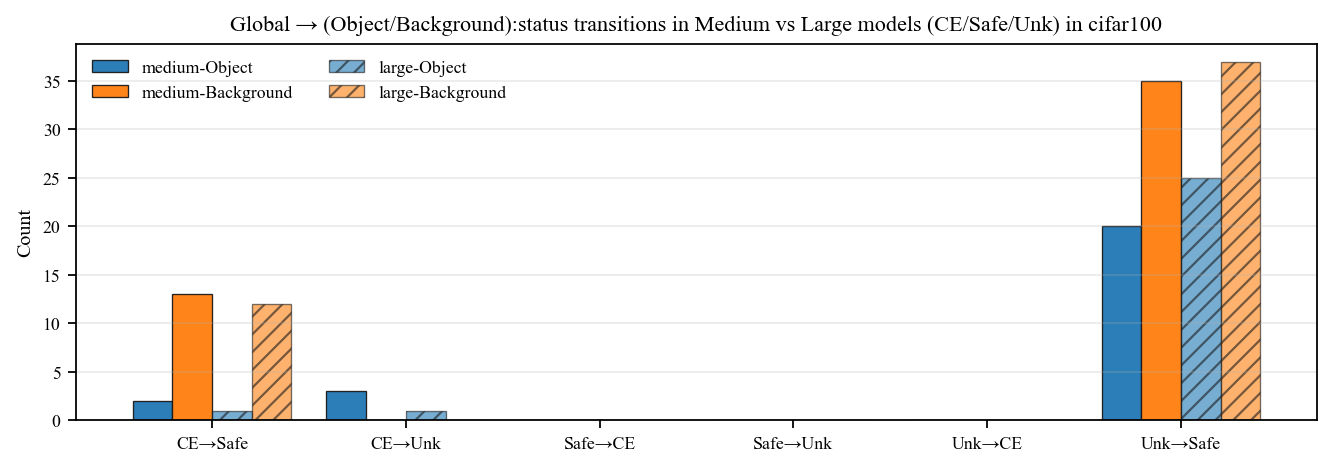

In [13]:
# =========================
# FULL CHUNK (paper-style)
# 1) 4 transition tables (Medium/Large × GO/GB) side-by-side, nicer colors
# 2) 1 grouped bar plot (6 transitions) with SAME COLOR per semantic,
#    and different HATCH (pattern) for Medium vs Large (more professional)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# -------------------------
# Paper-ish matplotlib style
# -------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -------------------------
# Load + normalize
# -------------------------

# model size
df["model_size"] = df["model"].astype(str).str.lower().apply(
    lambda x: "large" if "large" in x else ("medium" if "medium" in x else "other")
)

# tag -> semantic
TAG2SEM = {"global": "Global", "fix_nonmask": "Object", "fix_mask": "Background"}
df["semantic"] = df["tag"].astype(str).str.lower().map(TAG2SEM).fillna(df["tag"].astype(str))

# result -> CE/Safe/Unk
def result_to_status3(x: str) -> str:
    s = str(x).strip().lower()
    if s == "sat true":
        return "CE"
    if s == "timeout false":
        return "Unk"
    if s.startswith("unsat"):
        return "Safe"
    return "Unk"

df["status3"] = df["result"].apply(result_to_status3)

# numeric columns (optional)
for c in ["bab_time", "all_time", "domains_visited", "num_changed", "percent_changed", "k", "eps"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Rows:", len(df))
print("Model sizes:", df["model_size"].value_counts().to_dict())
print("Semantics:", df["semantic"].value_counts().to_dict())
print("status3:", df["status3"].value_counts().to_dict())

# -------------------------
# Transition table builder
# -------------------------
STATUS = ["CE", "Safe", "Unk"]

def transition_counts(df_sub: pd.DataFrame, A="Global", B="Object") -> pd.DataFrame:
    """
    Transition crosstab counts: rows=A status, cols=B status.
    One row per image (triplet), via pivot by semantic.
    """
    piv = df_sub.pivot_table(index="image", columns="semantic", values="status3", aggfunc="first")

    if (A not in piv.columns) or (B not in piv.columns):
        tab = pd.DataFrame(0, index=STATUS, columns=STATUS)
    else:
        piv2 = piv[[A, B]].dropna()
        tab = pd.crosstab(piv2[A], piv2[B]).reindex(index=STATUS, columns=STATUS, fill_value=0)

    tab = tab.astype(int)
    tab.loc["TOTAL"] = tab.sum(axis=0)
    tab["TOTAL"] = tab.sum(axis=1)
    return tab

# -------------------------
# Table styling (cleaner colors)
# -------------------------
def styler_transition(tab: pd.DataFrame, top_header: str, title: str):
    """
    Cleaner, paper-ish:
      - very light blue body rows
      - diagonal highlighted warm pale yellow
      - totals bold
      - subtle grid
    """
    t = tab.copy()
    t.index = pd.Index(t.index, name="Global status")
    t.columns = pd.Index(t.columns, name=top_header)

    base_styles = [
        {"selector": "table", "props": [
            ("border-collapse", "collapse"),
            ("font-family", "Arial"),
            ("font-size", "12px"),
        ]},
        {"selector": "caption", "props": [
            ("caption-side", "top"),
            ("font-weight", "700"),
            ("padding", "4px 0 8px 0"),
        ]},
        {"selector": "th", "props": [
            ("border", "1px solid #b7c4dd"),
            ("padding", "6px 10px"),
            ("background", "#ffffff"),
            ("color", "#111"),
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid #b7c4dd"),
            ("padding", "6px 10px"),
            ("color", "#111"),
        ]},
    ]

    def highlight_diag(data):
        out = pd.DataFrame("", index=data.index, columns=data.columns)
        for s in STATUS:
            if s in data.index and s in data.columns:
                out.loc[s, s] = "background-color: #ffe9a8;"  # warmer / more visible
        return out

    def shade_body_rows(data):
        out = pd.DataFrame("", index=data.index, columns=data.columns)
        # body rows
        for r in STATUS:
            if r in data.index:
                out.loc[r, :] = "background-color: #eef5ff;"  # slightly nicer blue
        # totals
        if "TOTAL" in data.index:
            out.loc["TOTAL", :] = "background-color: #ffffff; font-weight: 700;"
        if "TOTAL" in data.columns:
            out.loc[:, "TOTAL"] = out.loc[:, "TOTAL"] + " font-weight: 700;"
        return out

    sty = (
        t.style
        .set_caption(title)
        .set_table_styles(base_styles)
        .set_properties(**{"text-align": "center"})
        .apply(shade_body_rows, axis=None)
        .apply(highlight_diag, axis=None)
    )
    return sty

# -------------------------
# Display 4 tables in one view
# -------------------------
def display_four_tables(sty_m_go, sty_m_gb, sty_l_go, sty_l_gb):
    html = f"""
    <div style="display:flex; gap:22px; align-items:flex-start; flex-wrap:wrap;">
      <div style="flex:1; min-width:360px;">{sty_m_go.to_html()}</div>
      <div style="flex:1; min-width:360px;">{sty_m_gb.to_html()}</div>
      <div style="flex:1; min-width:360px;">{sty_l_go.to_html()}</div>
      <div style="flex:1; min-width:360px;">{sty_l_gb.to_html()}</div>
    </div>
    """
    display(HTML(html))

def show_all_transition_tables(df_all):
    # medium
    sub_m = df_all[df_all["model_size"] == "medium"].copy()
    tab_m_go = transition_counts(sub_m, "Global", "Object")
    tab_m_gb = transition_counts(sub_m, "Global", "Background")

    sty_m_go = styler_transition(tab_m_go, "Object status", "Medium — Global → Object (CE/Safe/Unk)")
    sty_m_gb = styler_transition(tab_m_gb, "Background status", "Medium — Global → Background (CE/Safe/Unk)")

    # large
    sub_l = df_all[df_all["model_size"] == "large"].copy()
    tab_l_go = transition_counts(sub_l, "Global", "Object")
    tab_l_gb = transition_counts(sub_l, "Global", "Background")

    sty_l_go = styler_transition(tab_l_go, "Object status", "Large — Global → Object (CE/Safe/Unk)")
    sty_l_gb = styler_transition(tab_l_gb, "Background status", "Large — Global → Background (CE/Safe/Unk)")

    display_four_tables(sty_m_go, sty_m_gb, sty_l_go, sty_l_gb)

# -------------------------
# One combined bar plot (more professional)
#   - Same color for semantic (Object vs Background)
#   - Different HATCH for model size (Medium vs Large)
#   - Thin outlines + light y-grid
# -------------------------
TRANS6 = [("CE","Safe"), ("CE","Unk"),
          ("Safe","CE"), ("Safe","Unk"),
          ("Unk","CE"), ("Unk","Safe")]

def get_trans6_from_tab(tab: pd.DataFrame):
    labels = []
    vals = []
    for a, b in TRANS6:
        labels.append(f"{a}→{b}")
        vals.append(int(tab.loc[a, b]) if (a in tab.index and b in tab.columns) else 0)
    return labels, np.array(vals, dtype=float)

def plot_all_transitions_one_plot(df_all, out_pdf=None):
    # Collect series
    # order: medium-object, medium-background, large-object, large-background
    series = []
    meta = []  # (model_size, semantic)

    for ms in ["medium", "large"]:
        sub = df_all[df_all["model_size"] == ms].copy()
        tab_go = transition_counts(sub, "Global", "Object")
        tab_gb = transition_counts(sub, "Global", "Background")

        labels, v_obj = get_trans6_from_tab(tab_go)
        _,      v_bg  = get_trans6_from_tab(tab_gb)

        series += [v_obj, v_bg]
        meta   += [(ms, "Object"), (ms, "Background")]

    x = np.arange(len(labels))
    n = len(series)  # 4
    group_width = 0.82
    w = group_width / n
    offsets = (np.arange(n) - (n-1)/2) * w

    # Professional styling: consistent colors by semantic, hatches by model_size
    semantic_color = {"Object": "#1f77b4", "Background": "#ff7f0e"}  # matplotlib defaults, safe for papers
    model_hatch = {"medium": "", "large": "///"}  # large uses hatch (pattern)
    model_alpha = {"medium": 0.95, "large": 0.60} # slightly lighter fill for large

    fig, ax = plt.subplots(figsize=(8.4, 3.0))

    for i in range(n):
        ms, sem = meta[i]
        ax.bar(
            x + offsets[i],
            series[i],
            width=w,
            label=f"{ms}-{sem}",
            color=semantic_color[sem],
            alpha=model_alpha[ms],
            hatch=model_hatch[ms],
            edgecolor="#1a1a1a",
            linewidth=0.6
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title("Global → (Object/Background):status transitions in Medium vs Large models (CE/Safe/Unk) in cifar100")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False, ncol=2, loc="upper left")

    fig.tight_layout()
    if out_pdf is not None:
        fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()

# =========================
# RUN
# =========================
show_all_transition_tables(df)
plot_all_transitions_one_plot(df, out_pdf="cifar100_transitions.pdf") 